## Standardization

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv("./Dataset/Social_Network_Ads.csv")

In [52]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [53]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

### Train_Test_split

In [54]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1) , df['Purchased'], test_size=0.3 ,random_state=42)
x_train.shape, x_test.shape

((280, 2), (120, 2))

### Standard Scaler

In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the details like mean, standard deviation etc from the data
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [56]:
# It learns from the data
scaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [57]:
# Numpy Array
x_train_scaled

array([[-0.84252154,  0.1301563 ],
       [ 0.04175763,  0.2777019 ],
       [ 0.72953032, -1.31579061],
       [ 1.61380949,  1.10395728],
       [ 0.82778356, -1.40431797],
       [-1.43204099, -1.25677236],
       [-0.05649561,  0.1301563 ],
       [ 0.43477059, -0.16493491],
       [-0.2530021 ,  0.01211982],
       [ 1.31904976,  2.22530386],
       [ 0.14001087,  0.74984783],
       [-1.33378775,  0.54328399],
       [ 2.00682245,  0.72033871],
       [-1.23553451, -1.43382709],
       [ 0.33651735, -0.34198963],
       [-0.94077478,  0.54328399],
       [ 0.43477059,  0.2777019 ],
       [ 0.43477059,  1.10395728],
       [ 0.82778356,  0.74984783],
       [ 0.9260368 ,  1.25150288],
       [-0.44950858, -1.25677236],
       [-1.82505395, -1.34529973],
       [ 1.12254328,  0.54328399],
       [-0.64601506, -1.64039093],
       [-0.7442683 ,  0.24819278],
       [ 1.02429004,  2.07775825],
       [-0.54776182,  1.36953936],
       [-0.05649561,  0.01211982],
       [-1.9233072 ,

In [58]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=['Age','Salary'])
x_test_scaled = pd.DataFrame(x_train_scaled, columns=['Age','Salary'])
x_train_scaled

,Age,Salary
0,-0.842522,0.130156
1,0.041758,0.277702
2,0.729530,-1.315791
3,1.613809,1.103957
4,0.827784,-1.404318
...,...,...
275,-1.333788,-1.286281
276,-1.137281,-1.050209
277,0.533024,1.841685
278,0.140011,0.189175


In [59]:
x_train.describe().round(1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.6,70589.3
std,10.2,33948.5
min,18.0,15000.0
25%,30.0,44000.0
50%,37.0,71000.0
75%,45.0,88000.0
max,60.0,150000.0


In [60]:
x_train_scaled.describe().round(1)

,Age,Salary
count,280.0,280.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.3


### Before & After Scaling

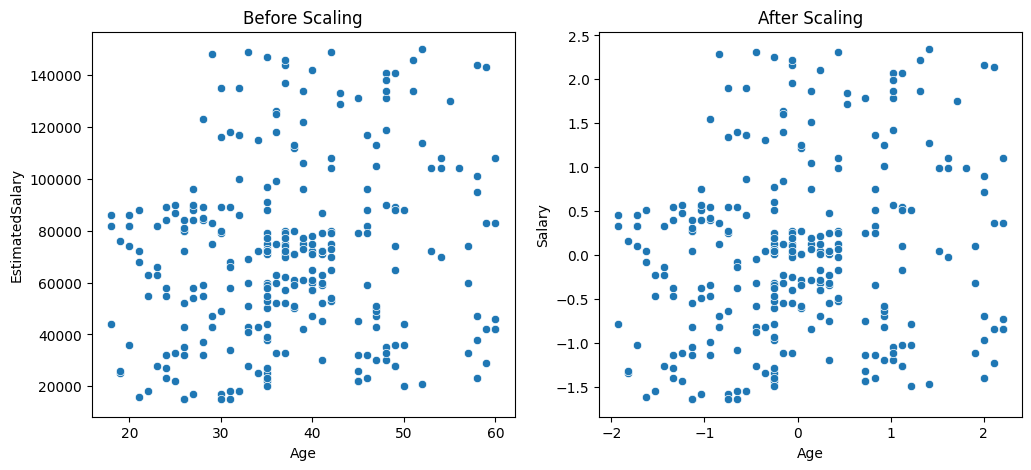

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data = x_train, x = 'Age', y = 'EstimatedSalary', ax = axes[0])
axes[0].set_title('Before Scaling')
sns.scatterplot(data = x_train_scaled, x = 'Age', y = 'Salary', ax= axes[1])
axes[1].set_title('After Scaling')
plt.show()

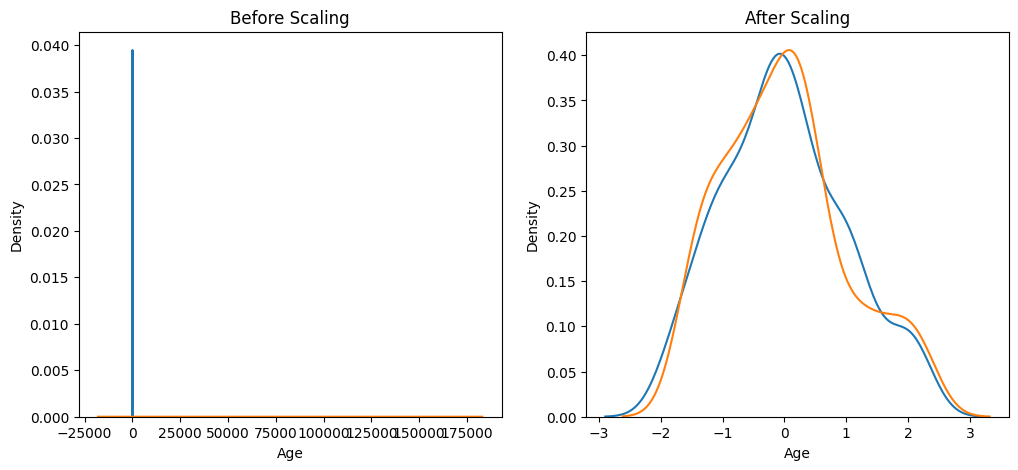

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(data = x_train, x = 'Age', ax = axes[0])
sns.kdeplot(data = x_train, x = 'EstimatedSalary', ax = axes[0])
axes[0].set_title('Before Scaling')
sns.kdeplot(data = x_train_scaled, x = 'Age', ax = axes[1])
sns.kdeplot(data = x_train_scaled, x = 'Salary', ax = axes[1])
axes[1].set_title('After Scaling')
plt.show()